# Decision boundaries: trees vs k-NN on two moons

Both models can learn complex decision boundaries. The key difference is how their behaviour changes as complexity is adjusted: tree depth controls decision trees, while the number of neighbours (k) controls k-NN.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

from scratchlearn.tree import DecisionTreeClassifier
from scratchlearn.neighbors import KNNClassifier
from scratchlearn.model_selection import train_test_split

X, y = make_moons(n_samples=400, noise=0.3, random_state=7)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


def plot_boundary(clf, ax, title):
    xx, yy = np.meshgrid(np.linspace(-2.0, 3.0, 300), np.linspace(-1.8, 2.2, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = clf.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=10)
    acc = clf.score(X_test, y_test)
    ax.set_title(f"{title}\ntest accuracy {acc:.2f}")
    ax.set_xticks([])
    ax.set_yticks([])

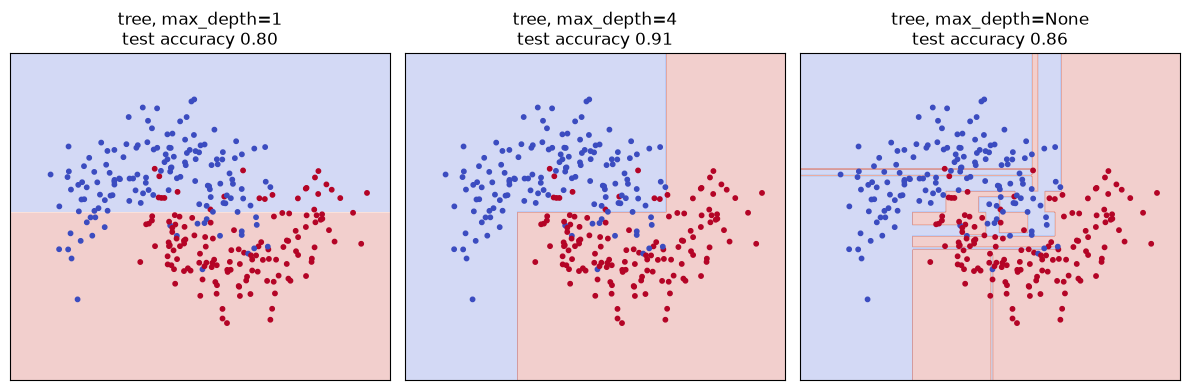

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, depth in zip(axes, [1, 4, None]):
    tree = DecisionTreeClassifier(max_depth=depth).fit(X_train, y_train)
    plot_boundary(tree, ax, f"tree, max_depth={depth}")
plt.tight_layout()

A depth-1 stump can only draw one axis-aligned line: high bias, and it underfits. The
unlimited tree earns perfect training accuracy by carving a box around every stray point:
high variance, and the test score drops back. Depth 4 sits between the two.

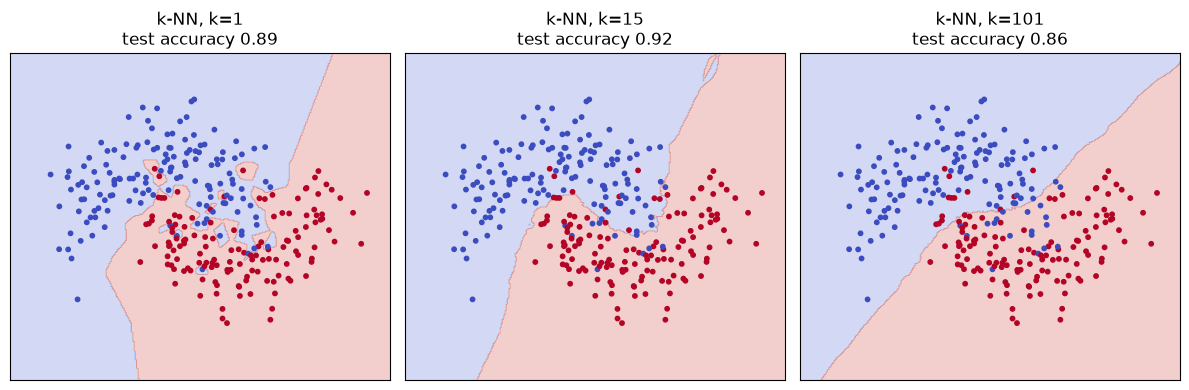

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(axes, [1, 15, 101]):
    knn = KNNClassifier(n_neighbors=k).fit(X_train, y_train)
    plot_boundary(knn, ax, f"k-NN, k={k}")
plt.tight_layout()

The same pattern appears in k-NN. With **k = 1**, the model effectively memorises the training data, while a large **k** produces a much smoother decision boundary by averaging over many nearby points. Both models follow the same bias-variance trade-off; only the parameter controlling complexity differs.